# Maps of mortality rates.

In [1]:
from thesis.util import centimeter_to_inch
import pandas as pd
import geobr
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import pathlib
from PIL import Image

## Loading data

In [2]:
df = pd.read_csv('data/df_mortality.csv', index_col=0)

In [3]:
df

,code_municipality_6,code_municipality_7,population,date,region,deaths,new_deaths,deaths_accumulated_first_semester_2020,delta_first_death_2020-06-30,deaths_accumulated_2020,...,expected_deaths_entire,SMR_1s_2020,expected_deaths_1s_2020,SMR_2020,expected_deaths_2020,SMR_2021,expected_deaths_2021,SMR_2022,expected_deaths_2022,inverse_death_weighted_SMR
0,110001,1100015,21495,2022-12-31,North,93.0,0.0,0.0,0.0,16.0,...,927589.0,0.000000,0.0,81.397176,165302.0,326.452891,662963.0,48.908622,99324.0,84.999061
1,110002,1100023,96833,2022-12-31,North,540.0,0.0,20.0,44.0,122.0,...,1457150.0,24.894038,50555.0,160.620832,326190.0,504.112758,1023756.0,52.788852,107204.0,123.047283
2,110003,1100031,5363,2022-12-31,North,15.0,0.0,1.0,0.0,4.0,...,480554.0,13.141078,26687.0,71.951180,146119.0,152.495985,309690.0,12.184808,24745.0,39.547968
3,110004,1100049,86895,2022-12-31,North,351.0,0.0,6.0,85.0,60.0,...,930313.0,7.787050,15814.0,77.981293,158365.0,343.801163,698194.0,36.317572,73754.0,77.494077
4,110005,1100056,15890,2022-12-31,North,76.0,0.0,2.0,41.0,8.0,...,1042295.0,12.169543,24714.0,57.032977,115823.0,383.454846,778723.0,72.753324,147748.0,102.197185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,522200,5222005,14956,2022-12-31,Midwestern,47.0,0.0,0.0,0.0,7.0,...,651089.0,0.000000,0.0,46.779420,95000.0,217.209158,441110.0,56.617871,114980.0,71.476035
5566,522205,5222054,8768,2022-12-31,Midwestern,34.0,0.0,1.0,20.0,8.0,...,973173.0,15.117139,30700.0,123.098813,249990.0,345.055836,700742.0,11.050776,22442.0,69.829597
5567,522220,5222203,4215,2022-12-31,Midwestern,7.0,0.0,0.0,0.0,2.0,...,653860.0,0.000000,0.0,96.067202,195094.0,116.817075,237233.0,109.086653,221534.0,107.162622
5568,522230,5222302,5815,2022-12-31,Midwestern,11.0,0.0,1.0,2.0,3.0,...,390316.0,21.654932,43977.0,58.049813,117888.0,121.589069,246924.0,12.558551,25504.0,33.621383


In [4]:
try:
    filename_map_municipalities = 'data/map_municipalities_2010.geojson'
    path_map_municipalities = pathlib.Path(filename_map_municipalities)
    map_municipalities = gpd.read_file(path_map_municipalities)

    filename_map_states = 'data/map_states_2010.geojson'
    path_map_states = pathlib.Path(filename_map_states)
    map_states = gpd.read_file(path_map_states)
except:
    map_municipalities = geobr.read_municipality(year=2010)
    map_states =  geobr.read_state(year=2010)
    map_municipalities.to_file('data/map_municipalities_2010.geojson', driver='GeoJSON')
    map_states.to_file('data/map_states_2010.geojson', driver='GeoJSON')

In [5]:
df_map_municipalities = map_municipalities.merge(df, how="left", left_on="code_muni", right_on="code_municipality_7")

In [6]:
df_map_municipalities = df_map_municipalities.loc[df_map_municipalities['name_muni'].isin(['Lagoa Mirim', 'Lagoa Dos Patos']) == False]

In [7]:
df_map_municipalities[df_map_municipalities['population'].isna()]

,code_muni,name_muni,code_state,abbrev_state,geometry,code_municipality_6,code_municipality_7,population,date,region,...,expected_deaths_entire,SMR_1s_2020,expected_deaths_1s_2020,SMR_2020,expected_deaths_2020,SMR_2021,expected_deaths_2021,SMR_2022,expected_deaths_2022,inverse_death_weighted_SMR
223,1504703.0,Moju,15.0,PA,"POLYGON ((-48.55770 -1.71801, -48.53041 -1.699...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4418,4207007.0,Içara,42.0,SC,"POLYGON ((-49.23878 -28.67659, -49.22586 -28.6...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4421,4207304.0,Imbituba,42.0,SC,"MULTIPOLYGON (((-48.64276 -28.15454, -48.64479...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4695,4304804.0,Carlos Barbosa,43.0,RS,"MULTIPOLYGON (((-51.49027 -29.27708, -51.49019...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5152,5005681.0,Mundo Novo,50.0,MS,"MULTIPOLYGON (((-54.36228 -23.90302, -54.36947...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Descriptive statistics

In [8]:
df.columns

Index(['code_municipality_6', 'code_municipality_7', 'population', 'date',
       'region', 'deaths', 'new_deaths',
       'deaths_accumulated_first_semester_2020',
       'delta_first_death_2020-06-30', 'deaths_accumulated_2020',
       'delta_first_death_2020-12-31', 'deaths_accumulated_2021',
       'delta_first_death_2021-12-31', 'delta_first_death_2022-12-31',
       'delta_first_death_general_period',
       'death_rate_accumulated_first_semester_2020',
       'death_rate_accumulated_2020', 'death_rate_accumulated_2021',
       'Death rate (accumulated period)', 'Death rate (2022)',
       'Death rate (2021)', 'Death rate (2020)', 'Death rate (1/2020)',
       'deaths_2022', 'deaths_2021', 'death_accumulated_2020_04',
       'death_accumulated_2020_04_rate', 'death_accumulated_2020_06',
       'death_accumulated_2020_06_rate', 'death_accumulated_2020_08',
       'death_accumulated_2020_08_rate', 'death_accumulated_2020_10',
       'death_accumulated_2020_10_rate', 'death_accumula

In [9]:
df[['SMR_1s_2020','SMR_2020', 'SMR_2021', 'SMR_2022', 'inverse_death_weighted_SMR']].describe().round(2)

,SMR_1s_2020,SMR_2020,SMR_2021,SMR_2022,inverse_death_weighted_SMR
count,5560.00,5560.00,5560.00,5560.00,5560.00
mean,16.43,65.34,168.71,28.71,51.17
std,29.57,52.10,92.72,24.58,26.10
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,27.71,98.84,12.14,32.00
50%,4.44,54.75,155.95,25.07,48.30
75%,19.55,92.00,223.98,39.93,67.00
max,280.80,487.67,582.06,431.99,321.84


## Map visualizations

In [10]:
custom_points = {}

point = map_states[map_states.abbrev_state == 'RJ'].geometry.centroid.values[0]
point = Point(point.x, point.y - 2.2)
custom_points['RJ'] = point

point = map_states[map_states.abbrev_state == 'SC'].geometry.centroid.values[0]
point = Point(point.x + 0.6, point.y - 0.8)
custom_points['SC'] = point

point = map_states[map_states.abbrev_state == 'ES'].geometry.centroid.values[0]
point = Point(point.x + 2.1, point.y - 1)
custom_points['ES'] = point

point = map_states[map_states.abbrev_state == 'SE'].geometry.centroid.values[0]
point = Point(point.x + 1.8, point.y - 1.5)
custom_points['SE'] = point

point = map_states[map_states.abbrev_state == 'AL'].geometry.centroid.values[0]
point = Point(point.x + 1.8, point.y - 1)
custom_points['AL'] = point

point = map_states[map_states.abbrev_state == 'PE'].geometry.centroid.values[0]
point = Point(point.x + 4.1, point.y - 0.7)
custom_points['PE'] = point

point = map_states[map_states.abbrev_state == 'PB'].geometry.centroid.values[0]
point = Point(point.x + 3.1, point.y - 0.5)
custom_points['PB'] = point

point = map_states[map_states.abbrev_state == 'RN'].geometry.centroid.values[0]
point = Point(point.x + 2.8, point.y)
custom_points['RN'] = point

point = map_states[map_states.abbrev_state == 'PI'].geometry.centroid.values[0]
point = Point(point.x + 1, point.y)
custom_points['PI'] = point

point = map_states[map_states.abbrev_state == 'DF'].geometry.centroid.values[0]
point = Point(point.x, point.y + 0.35)
custom_points['DF'] = point

point = map_states[map_states.abbrev_state == 'GO'].geometry.centroid.values[0]
point = Point(point.x, point.y - 1.4)
custom_points['GO'] = point

point = map_states[map_states.abbrev_state == 'AC'].geometry.centroid.values[0]
point = Point(point.x, point.y - 0.4)
custom_points['AC'] = point

<ipython-input-10-14fc443e71bc>:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  point = map_states[map_states.abbrev_state == 'RJ'].geometry.centroid.values[0]
<ipython-input-10-14fc443e71bc>:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  point = map_states[map_states.abbrev_state == 'SC'].geometry.centroid.values[0]
<ipython-input-10-14fc443e71bc>:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  point = map_states[map_states.abbrev_state == 'ES'].geometry.centroid.values[0]
<ipython-input-10-14fc443e71bc>:15: UserWarning: Geometry is in a geographic CRS. Results fro

In [11]:
df_map_municipalities.columns

Index(['code_muni', 'name_muni', 'code_state', 'abbrev_state', 'geometry',
       'code_municipality_6', 'code_municipality_7', 'population', 'date',
       'region', 'deaths', 'new_deaths',
       'deaths_accumulated_first_semester_2020',
       'delta_first_death_2020-06-30', 'deaths_accumulated_2020',
       'delta_first_death_2020-12-31', 'deaths_accumulated_2021',
       'delta_first_death_2021-12-31', 'delta_first_death_2022-12-31',
       'delta_first_death_general_period',
       'death_rate_accumulated_first_semester_2020',
       'death_rate_accumulated_2020', 'death_rate_accumulated_2021',
       'Death rate (accumulated period)', 'Death rate (2022)',
       'Death rate (2021)', 'Death rate (2020)', 'Death rate (1/2020)',
       'deaths_2022', 'deaths_2021', 'death_accumulated_2020_04',
       'death_accumulated_2020_04_rate', 'death_accumulated_2020_06',
       'death_accumulated_2020_06_rate', 'death_accumulated_2020_08',
       'death_accumulated_2020_08_rate', 'death_acc

In [19]:
def plot_map_mortality(df, width=34.8, height=52.2, nrows=3, ncols=2, filename_extra='',
                       columns = ['SMR_1s_2020', 'SMR_2020', 'SMR_2021', 'SMR_2022', 'SMR_entire'],
                       titles = ['(a) 2020 (first half)', '(b) 2020', '(c) 2021', '(d) 2022', '(e) 2020-2022'],
                       ignore_outliers = [False, False, False, False, False, False]):
    df = df.copy()

    linewidth_estados = 0.4
    # linewidth_municipios = linewidth_estados * 0.000001
    linewidth_municipios = 0

    sns.set(font_scale=1.1)
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(centimeter_to_inch(width), centimeter_to_inch(height)), nrows=nrows, ncols=ncols, subplot_kw=dict(aspect='equal'))
    ax = ax.ravel()
    
    for j  in range(len(columns)):
        column = columns[j]
        ax_atual = ax[j]
        
        outlier_threshold = df[column].quantile(0.75) + ((df[column].quantile(0.75) - df[column].quantile(0.25)) * 1.5)
        
        df_outliers = df.loc[((df[column] > outlier_threshold) & (ignore_outliers[j]==False)) | (df[column].isna())].copy()
        df_normal = df.loc[(df[column] <= outlier_threshold) | (ignore_outliers[j]==True) | (df[column].isna()) ]
        
        ax_atual.title.set_text(titles[j])

        missing_kwds = dict(color='grey', label='No data')

        normal_plot = df_normal.plot(
            column=column,
            cmap='OrRd',
            legend=True,            
            legend_kwds={"label": "Age-Sex Standardized Mortality Rate (ASMR)","orientation": "horizontal","pad": -0.025},
            edgecolor="gray",            
            linewidth=linewidth_municipios,
            categorical=False,    
            missing_kwds=missing_kwds,
            ax=ax_atual
        )
                
        if ignore_outliers[j] == False:
            df_outliers.loc[df_outliers[column] > 0, 'outlier'] = 'Outlier (> ' + str(round(outlier_threshold, 2))+')'
            outlier_plot = df_outliers.plot(
                column='outlier',
                cmap='tab20b',            
                legend=True,
                edgecolor="gray",
                linewidth=linewidth_municipios,
                categorical=True,
                missing_kwds=missing_kwds,
                legend_kwds={'bbox_to_anchor': (1.1,1.0)},
                ax=ax_atual
            )     
            # if j == 0:
            #     labels = outlier_plot.get_legend().texts
            #     handles = outlier_plot.get_legend().legend_handles
            #     fig.legend(handles=handles, labels=[label.get_text() for label in labels],loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.025))
            #     outlier_plot.legend([], frameon=False)

        map_states.boundary.plot(edgecolor="black", linewidth=linewidth_estados, ax=ax_atual)

        map_states[map_states.abbrev_state.isin(['RJ', 'SC', 'ES', 'SE', 'AL', 'PE', 'PB', 'RN', 'DF', 'GO', 'PI', 'AC']) == False].apply(lambda x: ax_atual.annotate(text=x.abbrev_state, xy=x.geometry.centroid.coords[0], ha='center'), axis=1)

        for point in custom_points.keys():
            ax_atual.text(custom_points[point].x, custom_points[point].y, point, ha='center')

        ax_atual.axis("off")
                    
    if (len(columns)%2 != 0) & (nrows > 1):
        ax[len(columns)].remove()

    fig.tight_layout()

    fig.savefig('images/map_moratality_years'+filename_extra+'.png', bbox_inches="tight")    
    fig.savefig('images/map_moratality_years'+filename_extra+'.pdf', bbox_inches="tight")

    plt.savefig('images/map_moratality_years'+filename_extra+'.tiff', format='tiff', dpi=300, transparent=False, bbox_inches='tight')
    img = Image.open('images/map_moratality_years'+filename_extra+'.tiff')
    img.save('images/map_moratality_years'+filename_extra+'_compressed.tiff', compression="tiff_lzw")    
    plt.show()

In [20]:
def plot_map_mortality_single(df, width=17.4, height=17.4, filename_extra='accumulated_period',
                       column = 'SMR_entire',
                       ignore_outlier = False):
    df = df.copy()

    linewidth_estados = 0.4
    # linewidth_municipios = linewidth_estados * 0.000001
    linewidth_municipios = 0

    sns.set(font_scale=1.1)
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(centimeter_to_inch(width), centimeter_to_inch(height)))
    
    outlier_threshold = df[column].quantile(0.75) + ((df[column].quantile(0.75) - df[column].quantile(0.25)) * 1.5)
    
    df_outliers = df.loc[((df[column] > outlier_threshold) & (ignore_outlier==False)) | (df[column].isna())].copy()
    df_normal = df.loc[(df[column] <= outlier_threshold) | (ignore_outlier==True) | (df[column].isna()) ]

    missing_kwds = dict(color='grey', label='No data')

    normal_plot = df_normal.plot(
        column=column,
        cmap='OrRd',
        legend=True,            
        legend_kwds={"label": "Age-Sex Standardized Mortality Rate (ASMR)","orientation": "horizontal","pad": -0.025},
        edgecolor="gray",            
        linewidth=linewidth_municipios,
        categorical=False,    
        missing_kwds=missing_kwds,
        ax=ax
    )
            
    if ignore_outlier == False:
        df_outliers.loc[df_outliers[column] > 0, 'outlier'] = 'Outlier'
        outlier_plot = df_outliers.plot(
            column='outlier',
            cmap='tab20b',            
            legend=True,            
            edgecolor="gray",
            linewidth=linewidth_municipios,
            categorical=True,
            missing_kwds=missing_kwds,
            legend_kwds={'bbox_to_anchor': (1.1,1.0)},
            ax=ax
        )     
        
        labels = outlier_plot.get_legend().texts
        handles = outlier_plot.get_legend().legend_handles
        fig.legend(handles=handles, labels=[label.get_text() for label in labels],loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.025))
        outlier_plot.legend([], frameon=False) 

    map_states.boundary.plot(edgecolor="black", linewidth=linewidth_estados, ax=ax)

    map_states[map_states.abbrev_state.isin(['RJ', 'SC', 'ES', 'SE', 'AL', 'PE', 'PB', 'RN', 'DF', 'GO', 'PI', 'AC']) == False].apply(lambda x: ax.annotate(text=x.abbrev_state, xy=x.geometry.centroid.coords[0], ha='center'), axis=1)

    for point in custom_points.keys():
        ax.text(custom_points[point].x, custom_points[point].y, point, ha='center')

    ax.axis("off")

    fig.tight_layout()

    fig.savefig('images/map_moratality_years'+filename_extra+'.png', bbox_inches="tight")    
    fig.savefig('images/map_moratality_years'+filename_extra+'.pdf', bbox_inches="tight")

    plt.show()

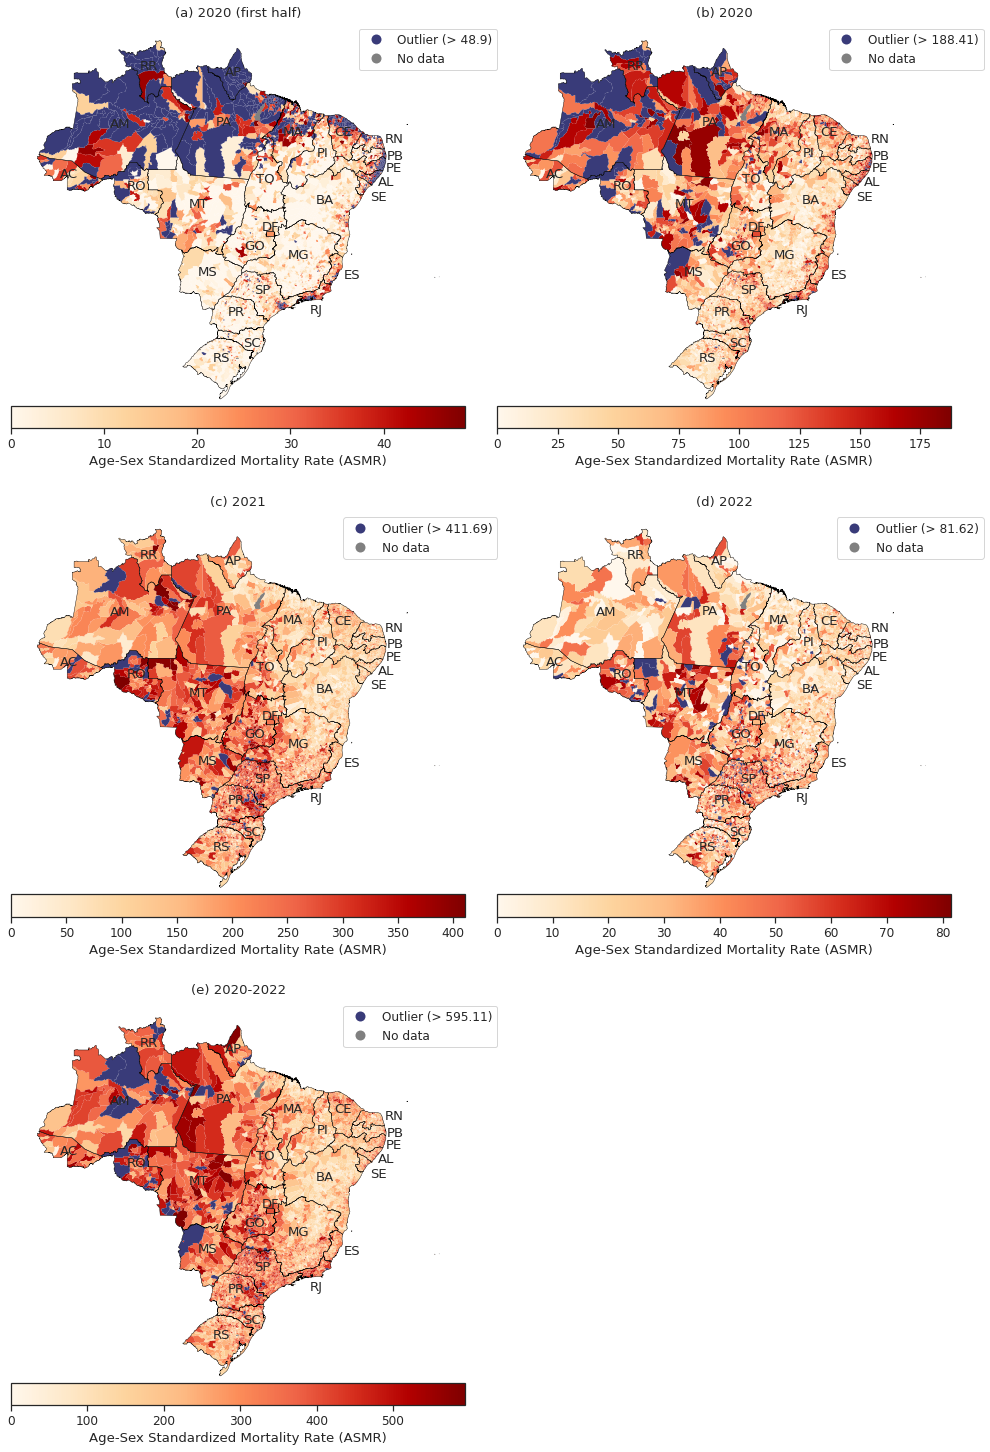

In [21]:
handles = plot_map_mortality(df_map_municipalities)

<ipython-input-20-670f4c2f66fd>:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  outlier_plot.legend([], frameon=False)


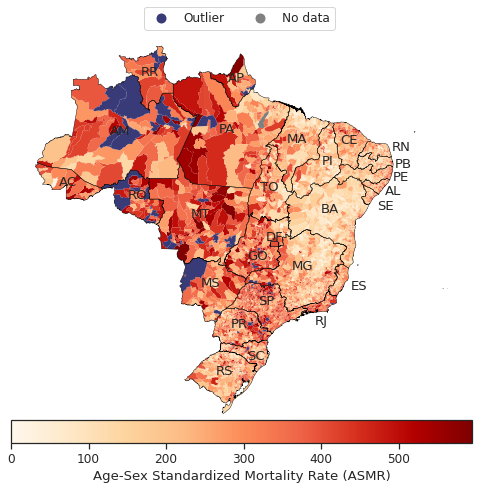

In [22]:
plot_map_mortality_single(df_map_municipalities)

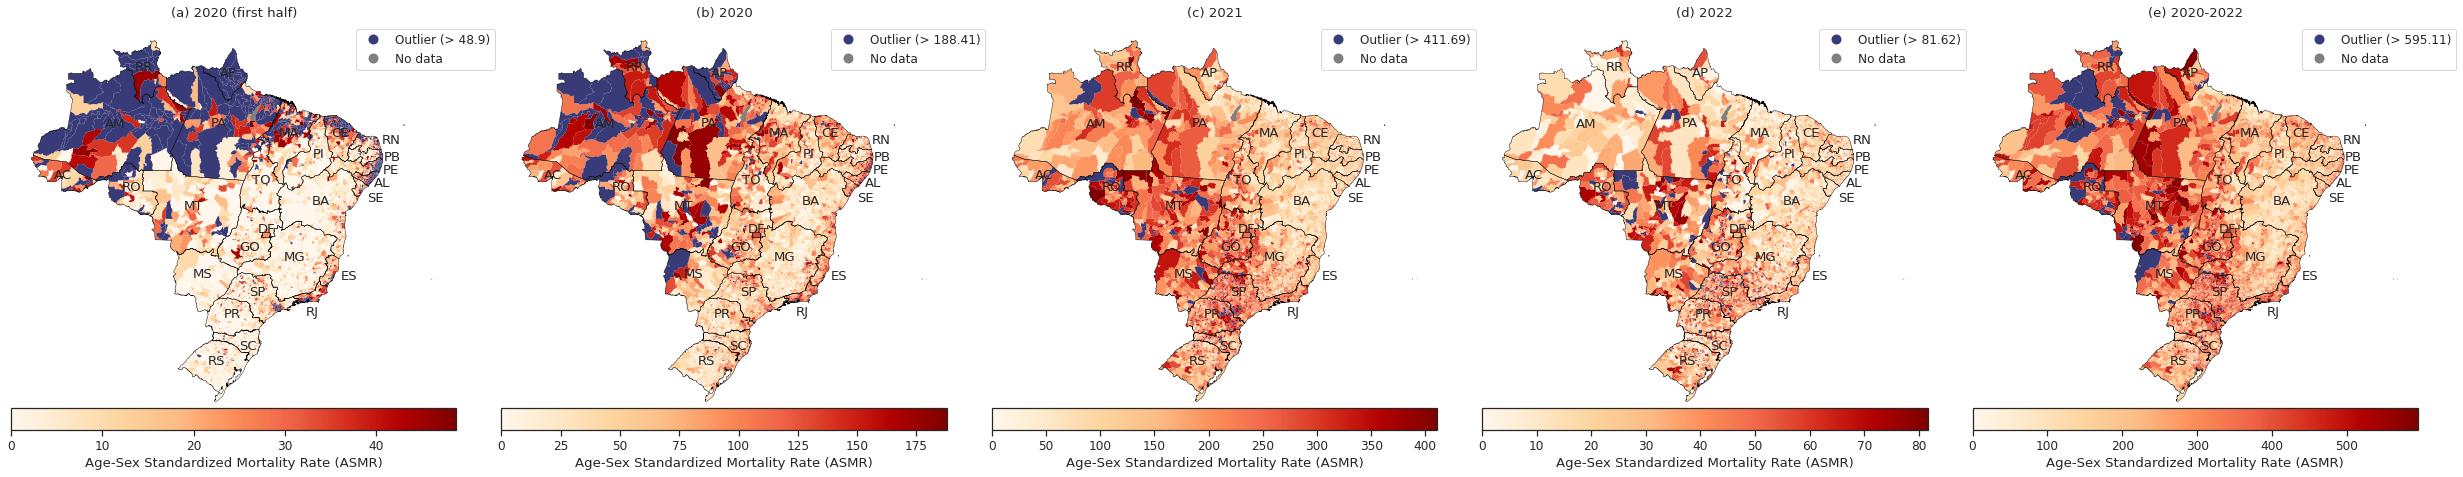

In [23]:
plot_map_mortality(df_map_municipalities, width=87, height=17.4, nrows=1, ncols=5, filename_extra='slide')

## Analysis per region

In [24]:
df = df.sort_values('region')

SMR_1s_2020


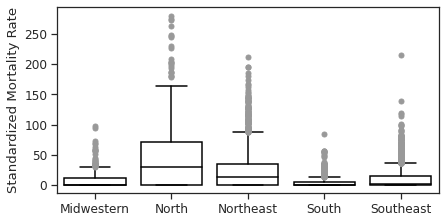

SMR_2020


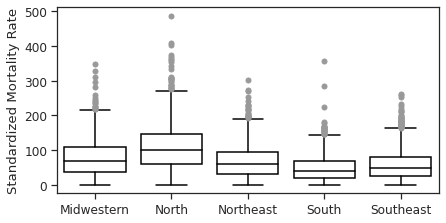

SMR_2021


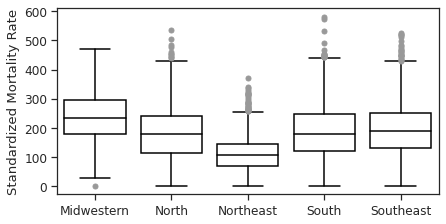

SMR_2022


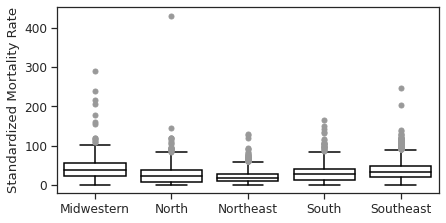

SMR_entire


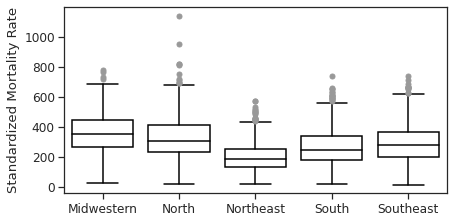

In [26]:
for moment in ['SMR_1s_2020', 'SMR_2020', 'SMR_2021', 'SMR_2022', 'SMR_entire']:
    print(moment)
    sns.set(font_scale=1.1)
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(centimeter_to_inch(17.4), centimeter_to_inch(8.7)))

    # Customizing the boxplot to have black boxlines and outliers
    sns.boxplot(
        data=df,
        y=moment,
        x='region',
        color='white',
        boxprops=dict(facecolor='white', edgecolor='black'),  # Box properties
        whiskerprops=dict(color='black'),                    # Whisker properties
        capprops=dict(color='black'),                        # Cap properties
        medianprops=dict(color='black'),                     # Median line properties
        flierprops=dict(marker='o', color='black', markersize=5)  # Outliers properties
    )

    # Set the color of the edges of the boxes and lines inside the plot
    plt.setp(ax.artists, edgecolor='black', facecolor='white')
    plt.setp(ax.lines, color='black')

    # Set labels
    plt.ylabel('Standardized Mortality Rate')
    plt.xlabel(None)

    # Save the figure
    plt.savefig('images/boxplot_deaths_municipalities_'+moment+'.pdf', bbox_inches="tight")

    # Show the plot
    plt.show()